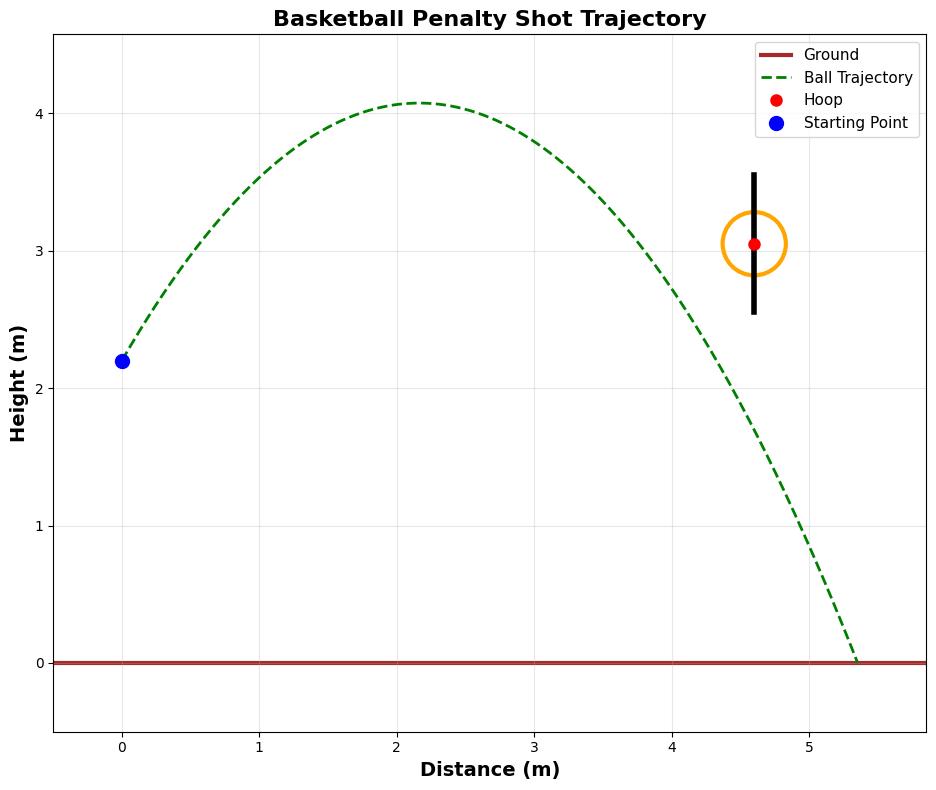

Initial velocity: 7 m/s at 60° angle
Initial height: 2.2 m
Hoop position: (4.6 m, 3.05 m)
Ball height at hoop distance: 1.69 m
Difference from hoop: -1.36 m
Total trajectory distance: 5.35 m
Maximum height: 4.07 m
Result: Ball passes BELOW the hoop.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Given parameters
v0 = 7  # initial velocity in m/s
angle = 60  # angle in degrees
angle_rad = np.radians(angle)  # convert to radians
h0 = 2.2  # initial height in meters
g = 9.81  # gravity in m/s^2
hoop_x = 4.6  # hoop distance in meters
hoop_y = 3.05  # hoop height in meters

# Velocity components
v0x = v0 * np.cos(angle_rad)
v0y = v0 * np.sin(angle_rad)

# Calculate time when ball hits the ground (y = 0)
# Using quadratic formula: 0 = h0 + v0y*t - 0.5*g*t^2
# Rearranged: -0.5*g*t^2 + v0y*t + h0 = 0
a = -0.5 * g
b = v0y
c = h0

t_ground = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)

# Create time array from 0 to when ball hits ground
t = np.linspace(0, t_ground, 1000)

# Calculate trajectory
x = v0x * t
y = h0 + v0y * t - 0.5 * g * t**2

# Create the plot
plt.figure(figsize=(12, 8))

# Plot ground line (highlighted)
plt.axhline(y=0, color='brown', linewidth=3, label='Ground', zorder=1)

# Plot trajectory with green dashed line
plt.plot(x, y, 'g--', linewidth=2, label='Ball Trajectory', zorder=2)

# Represent the hoop (using a circle with backboard)
circle = plt.Circle((hoop_x, hoop_y), 0.23, color='orange', fill=False, linewidth=3, zorder=3)
plt.gca().add_patch(circle)
# Add backboard
plt.plot([hoop_x, hoop_x], [hoop_y - 0.5, hoop_y + 0.5], 'k-', linewidth=4, zorder=3)
plt.plot(hoop_x, hoop_y, 'ro', markersize=8, label='Hoop', zorder=4)

# Mark initial position
plt.plot(0, h0, 'bo', markersize=10, label='Starting Point', zorder=4)

# Axis labels
plt.xlabel('Distance (m)', fontsize=14, fontweight='bold')
plt.ylabel('Height (m)', fontsize=14, fontweight='bold')
plt.title('Basketball Penalty Shot Trajectory', fontsize=16, fontweight='bold')

# Grid and legend
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=11)

# Set axis limits with some padding
plt.xlim(-0.5, max(x) + 0.5)
plt.ylim(-0.5, max(y) + 0.5)

# Equal aspect ratio for better visualization
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('basketball_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate if the ball goes through the hoop
# Find the height at x = 4.6m
t_at_hoop = hoop_x / v0x
y_at_hoop = h0 + v0y * t_at_hoop - 0.5 * g * t_at_hoop**2

print(f"Initial velocity: {v0} m/s at {angle}° angle")
print(f"Initial height: {h0} m")
print(f"Hoop position: ({hoop_x} m, {hoop_y} m)")
print(f"Ball height at hoop distance: {y_at_hoop:.2f} m")
print(f"Difference from hoop: {y_at_hoop - hoop_y:.2f} m")
print(f"Total trajectory distance: {x[-1]:.2f} m")
print(f"Maximum height: {max(y):.2f} m")
if abs(y_at_hoop - hoop_y) < 0.23:
    print("Result: BASKET! Ball goes through the hoop.")
else:
    if y_at_hoop > hoop_y:
        print("Result: Ball passes ABOVE the hoop.")
    else:
        print("Result: Ball passes BELOW the hoop.")
